In [1]:
from importlib import util

if util.find_spec("starforge") is None:
    ! cd ../ && pip install -e .

if util.find_spec("pandas") is None:
    ! pip install pandas

if util.find_spec("plotly") is None:
    ! pip install plotly
    !pip install nbformat

# !pip install pydantic-numpy


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from starforge.blackholes.accretionrate.blackholesaccretionrate import BlackHolesAccretionRate, ParameterAccretionRate
from starforge.blackholes.discreteblackholemf import BlackHolesMassFunction
from starforge.cosmology.lcdmmodel import LCDMModel
from starforge.cosmology.cosmologicalparameters import CosmologicalParameters



2025-11-08 09:22:39.719601: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [27]:
eta = 0.1  # radiative efficiency
lcdmUniverser = LCDMModel(CosmologicalParameters())

params = ParameterAccretionRate(
    lb_mean_par=7.96e13,  # L_{sun}
    mbh_par=2.19e11,
    alpha_par=2.71e-1,
    tau_par=4.81e9, #yr
    eta_par=eta,
    t_q_par=1.0e9, #yr
    b1_par=0.01,
    b2_par=0.1,
)
accretion = BlackHolesAccretionRate(cosmology=lcdmUniverser, params=params)
solver = BlackHolesMassFunction(accretion)

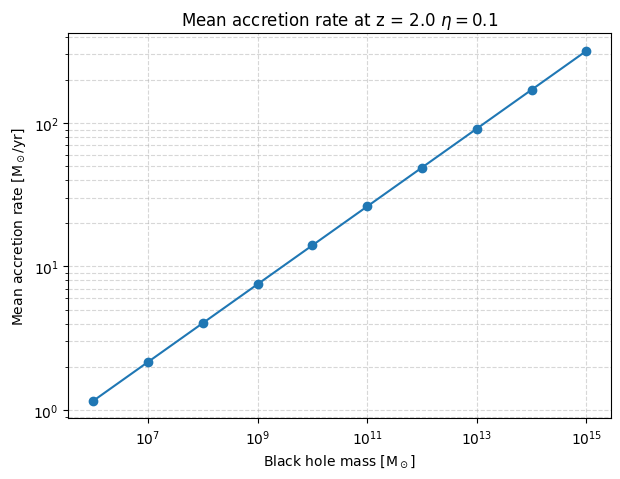

Mbh = 1.0e+06 M_sun -> mdot(z=2.0) = 1.000e+06 M_sun/yr
Mbh = 1.0e+08 M_sun -> mdot(z=2.0) = 1.000e+08 M_sun/yr
Mbh = 1.0e+10 M_sun -> mdot(z=2.0) = 1.000e+10 M_sun/yr


In [28]:
# Choose a test redshift and mass range
z_test = 2.0   # you can vary: 0.5, 1, 2, 5, ...
masses = np.logspace(6, 15, 10)  # black hole masses from 1e6 to 1e10 M_sun

mdot_values = [accretion.mean_accretion_rate(z_test, m) for m in masses]

# Plot mean accretion rate vs. mass
plt.figure(figsize=(7,5))
plt.loglog(masses, mdot_values, marker="o")
plt.xlabel(r"Black hole mass [M$_\odot$]")
plt.ylabel(r"Mean accretion rate [M$_\odot$/yr]")
plt.title(f"Mean accretion rate at z = {z_test}" + r" $\eta = $" + f"{eta}")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# Also print some reference values
for m in [1e6, 1e8, 1e10]:
    mdot_val = accretion.mean_accretion_rate(z_test, m)
    print(f"Mbh = {m:.1e} M_sun -> mdot(z={z_test}) = {m:.3e} M_sun/yr")

In [29]:
# Gaussian test distribution in log-mass space
def gaussian(x, mu, sigma):
    return np.exp(-0.5*((x-mu)/sigma)**2)

mbh_i, mbh_f, mbh_steps = 6, 15, 100  # log10(M/Msun) grid
masses_log = np.linspace(mbh_i, mbh_f, mbh_steps)

norm = 1e-3  # normalization factor

initial_condition = norm * gaussian(masses_log, mu=8, sigma=1.5)
# =4.4643133042084955 z_final=1.1985741398361522

In [30]:
z_i, z_f, z_steps = 4.4643133042084955, 1.1985741398361522, mbh_steps * 1000
outputs = solver.solver(initial_condition, z_i, mbh_i, z_f, mbh_f, z_steps, mbh_steps, verbose=True)

z steps: 0it [00:00, ?it/s]

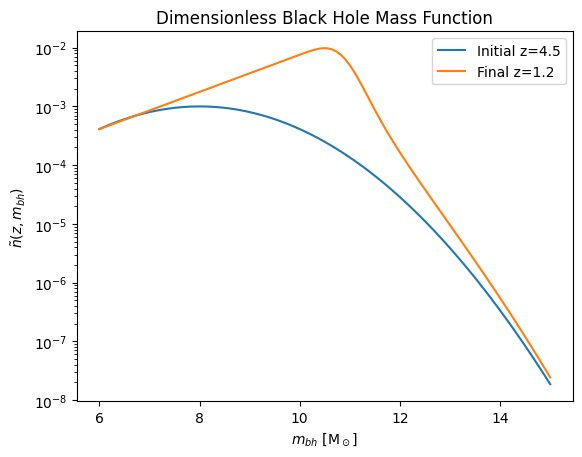

In [31]:
plt.plot(outputs.ln_mbh_grid, outputs.n_initial, label=f"Initial z={z_i:.1f}")
plt.plot(outputs.ln_mbh_grid, outputs.n_final, label=f"Final z={z_f:.1f}")
plt.legend()
plt.yscale("log")
plt.xlabel(r"$m_{bh}$ [M$_\odot$]")
plt.ylabel(r"$\tilde{n}(z, m_{bh})$")
plt.title("Dimensionless Black Hole Mass Function")
plt.show()

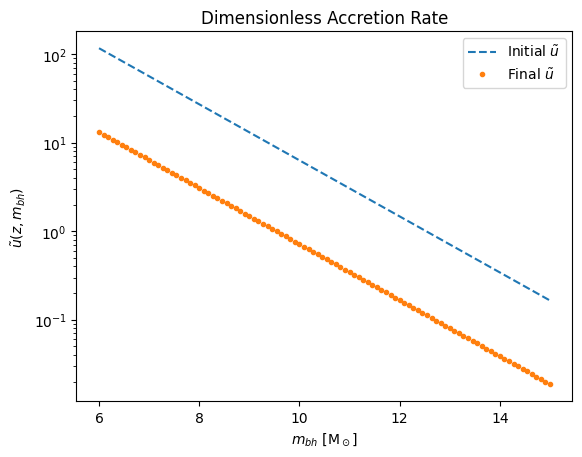

In [32]:
plt.plot(outputs.ln_mbh_grid, outputs.u_initial, '--', label=r"Initial $\tilde{u}$")
plt.plot(outputs.ln_mbh_grid,  outputs.u_final, '.', label=r"Final $\tilde{u}$")
plt.legend()
plt.yscale("log")
plt.xlabel(r"$m_{bh}$ [M$_\odot$]")
plt.ylabel(r"$\tilde{u}(z, m_{bh})$")
plt.title("Dimensionless Accretion Rate")
plt.show()